# Churn prediction


## Predict customer churn and identify high-risk customers to reduce revenue loss

## Business Problem

Customer churn leads to significant revenue loss. The objective of this project is to:
- Predict which customers are likely to churn
- Identify key factors driving churn
- Segment customers into risk categories
- Provide actionable strategies to reduce churn

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("data_ecommerce_customer_churn.csv")
df.head()



,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Watch,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


## Data Cleaning

- Missing values were handled using median imputation for numerical features
- Categorical values were standardized (lowercase, trimmed spaces)
- Duplicate records were removed

This ensures consistency and improves model performance.

In [3]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

In [4]:
df = df.drop_duplicates()
df.fillna(df.median(numeric_only=True), inplace=True)

In [5]:
Cat_cols = df.select_dtypes(include = 'object').columns
for col in Cat_cols:
    df[col] = df[col].str.strip().str.lower()

In [6]:
df_original = df.copy() # save original clean data

## EDA

In [7]:
print(df.groupby('Churn')['Tenure'].mean())
print(df.groupby('Churn')['DaySinceLastOrder'].mean())
print(df.groupby('Churn')['SatisfactionScore'].mean())
print(df.groupby('Churn')['Complain'].mean())

Churn
0    11.386330
1     3.705993
Name: Tenure, dtype: float64
Churn
0    4.688231
1    3.290262
Name: DaySinceLastOrder, dtype: float64
Churn
0    2.960161
1    3.331461
Name: SatisfactionScore, dtype: float64
Churn
0    0.229532
1    0.548689
Name: Complain, dtype: float64


In [8]:
print(pd.crosstab(df['PreferedOrderCat'], df['Churn'], normalize='index'))
print(pd.crosstab(df['MaritalStatus'], df['Churn'], normalize='index'))

Churn                      0         1
PreferedOrderCat                      
fashion             0.845041  0.154959
grocery             0.958506  0.041494
laptop & accessory  0.901896  0.098104
mobile phone        0.731034  0.268966
others              0.926174  0.073826
watch               0.729258  0.270742
Churn                 0         1
MaritalStatus                    
divorced       0.845486  0.154514
married        0.890866  0.109134
single         0.741071  0.258929


--> Key observations:

- Customers who churn have significantly lower tenure (~3.7) compared to retained customers (~11.3)
  → New customers are at higher risk

- Customers who churn show slightly higher days since last order
  → Inactive users are more likely to churn

- Customers who filed complaints have a much higher churn rate
  → Complaint resolution is critical

- Certain product categories (e.g., mobile) show higher churn rates
  → Product experience may influence retention

### Data Visualization

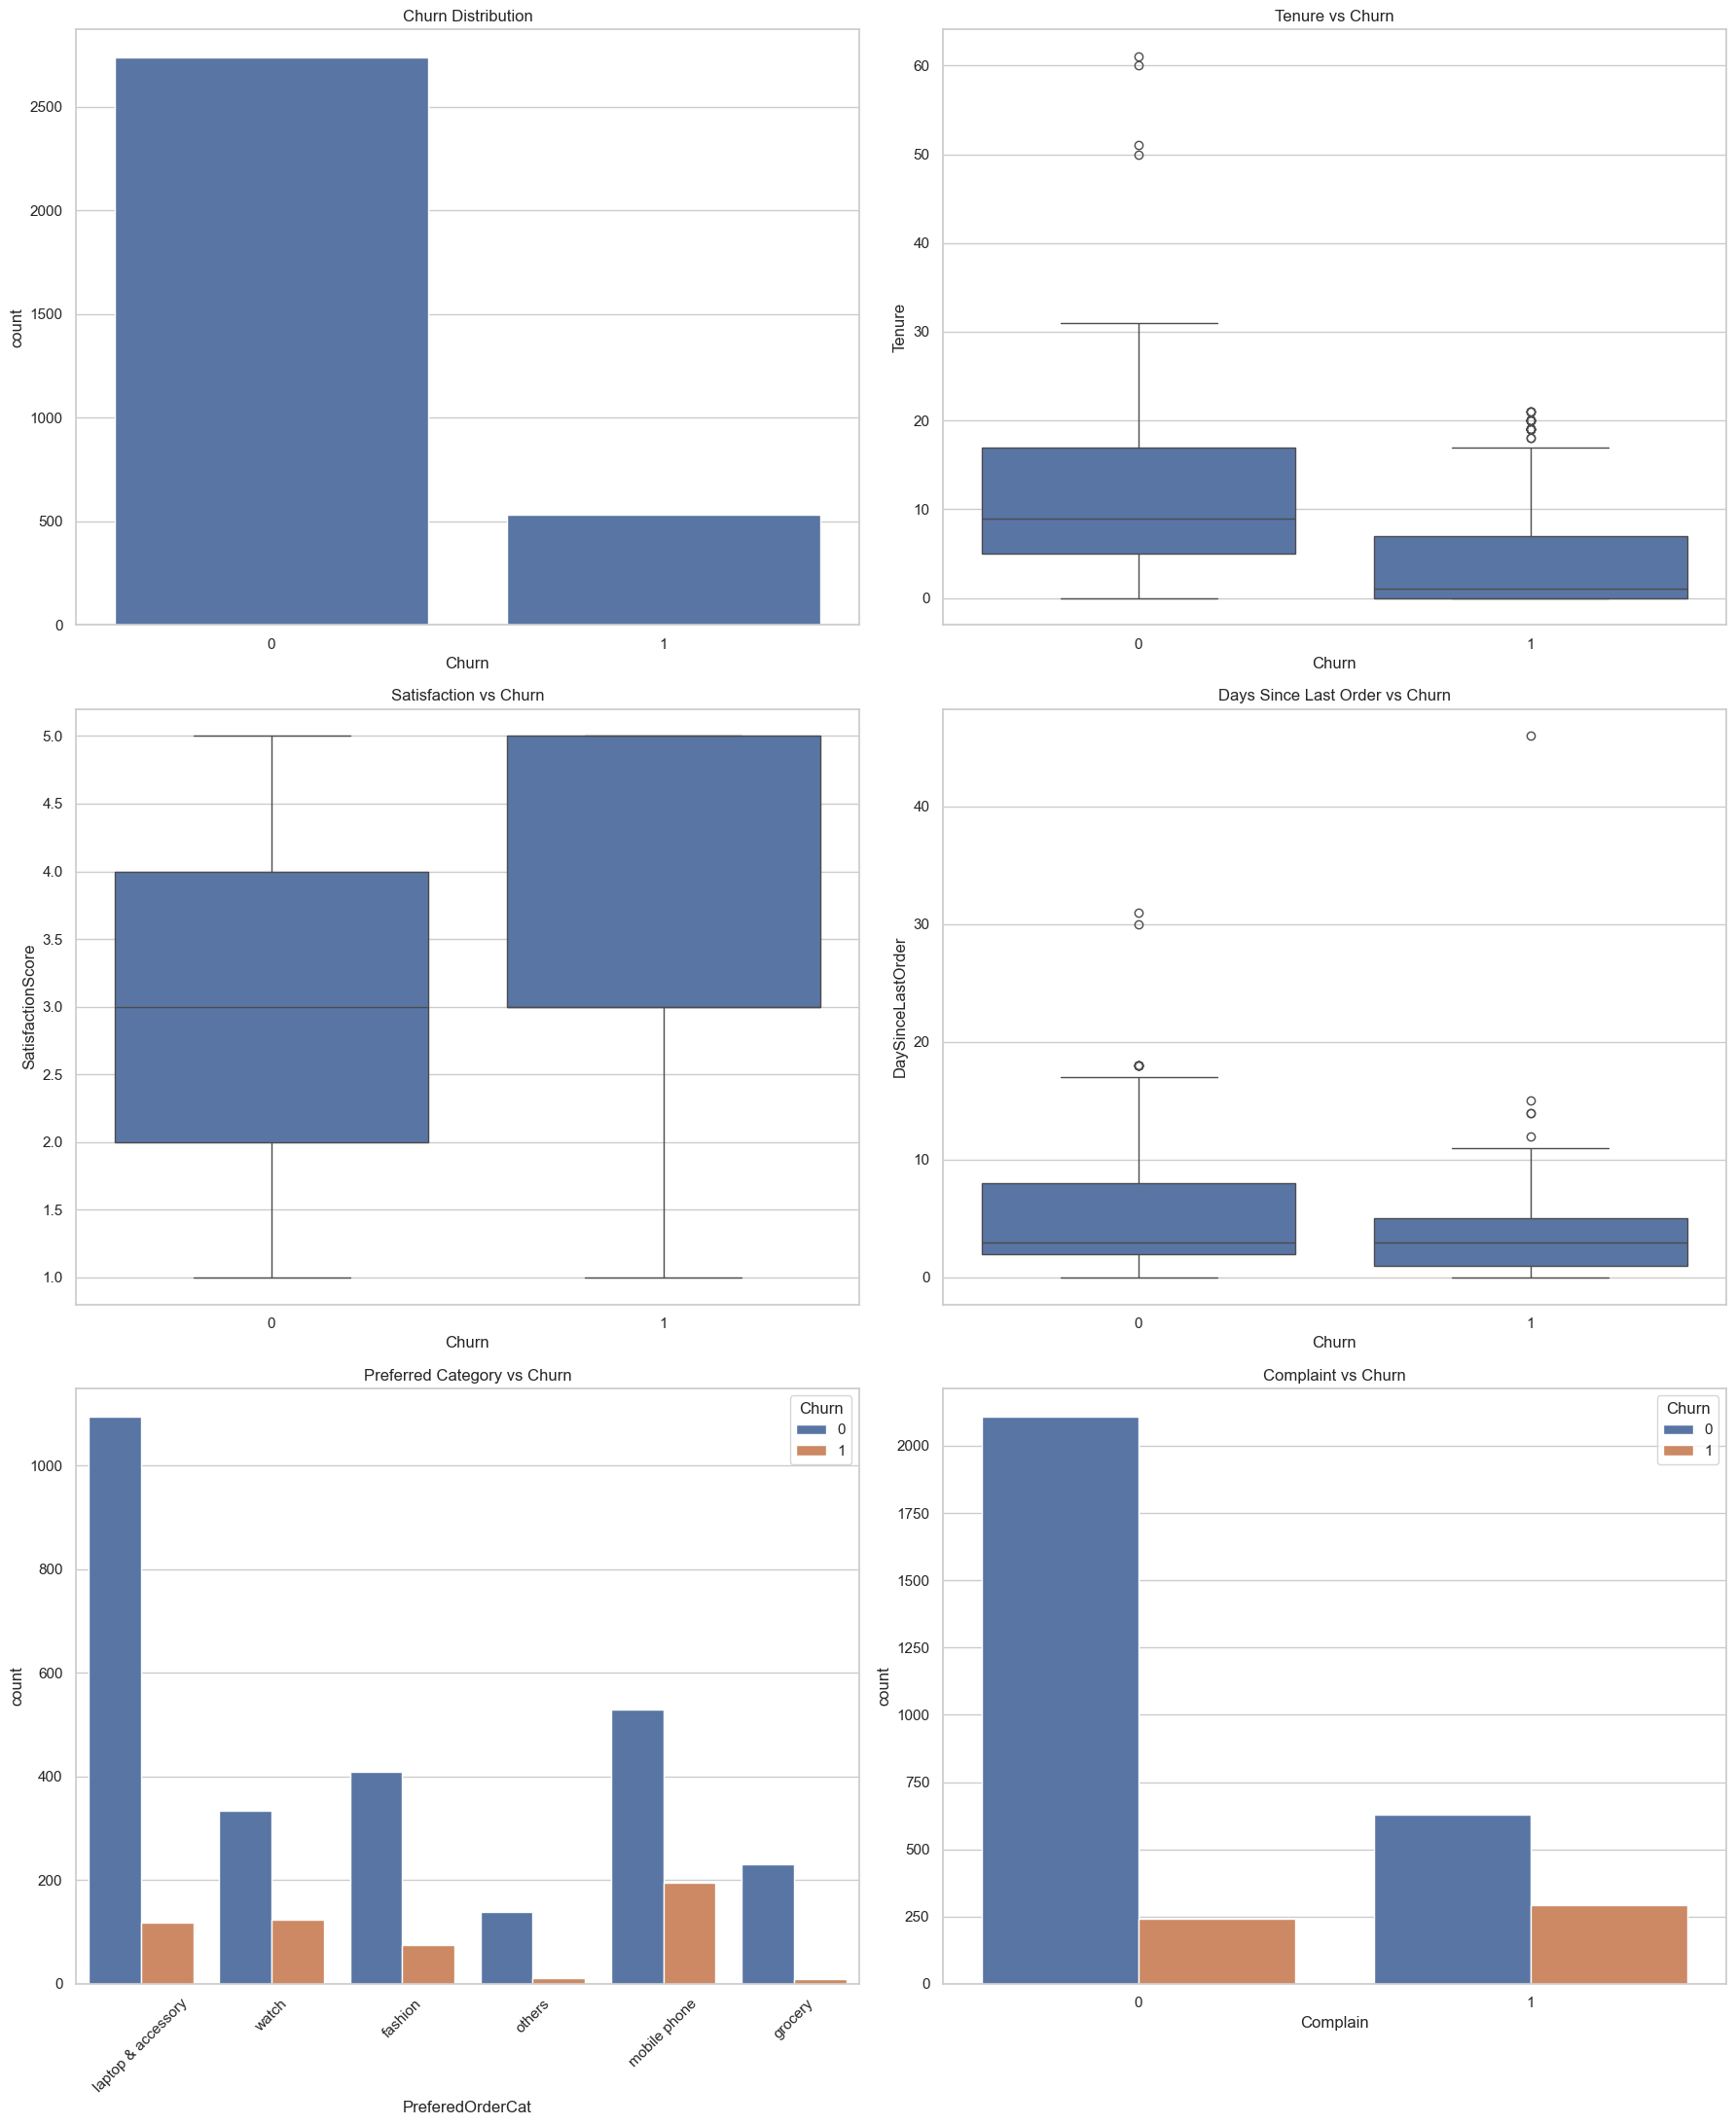

In [10]:
# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(18, 22))

# 1. Churn Distribution
plt.subplot(3, 2, 1)
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")

# 2. Tenure vs Churn
plt.subplot(3, 2, 2)
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title("Tenure vs Churn")

# 3. Satisfaction vs Churn
plt.subplot(3, 2, 3)
sns.boxplot(x='Churn', y='SatisfactionScore', data=df)
plt.title("Satisfaction vs Churn")

# 4. Inactivity vs Churn
plt.subplot(3, 2, 4)
sns.boxplot(x='Churn', y='DaySinceLastOrder', data=df)
plt.title("Days Since Last Order vs Churn")

# 5. Preferred Category vs Churn
plt.subplot(3, 2, 5)
sns.countplot(x='PreferedOrderCat', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Preferred Category vs Churn")

# 6. Complaint vs Churn
plt.subplot(3, 2, 6)
sns.countplot(x='Complain', hue='Churn', data=df)
plt.title("Complaint vs Churn")

# Adjust layout
plt.tight_layout()

# Show all plots
plt.show()

--> Visual analysis confirms:
- Churned customers tend to have shorter tenure
- Higher inactivity strongly correlates with churn
- Complaint behavior is a strong churn indicator

These insights guide feature selection and model building.

## Check outliers 

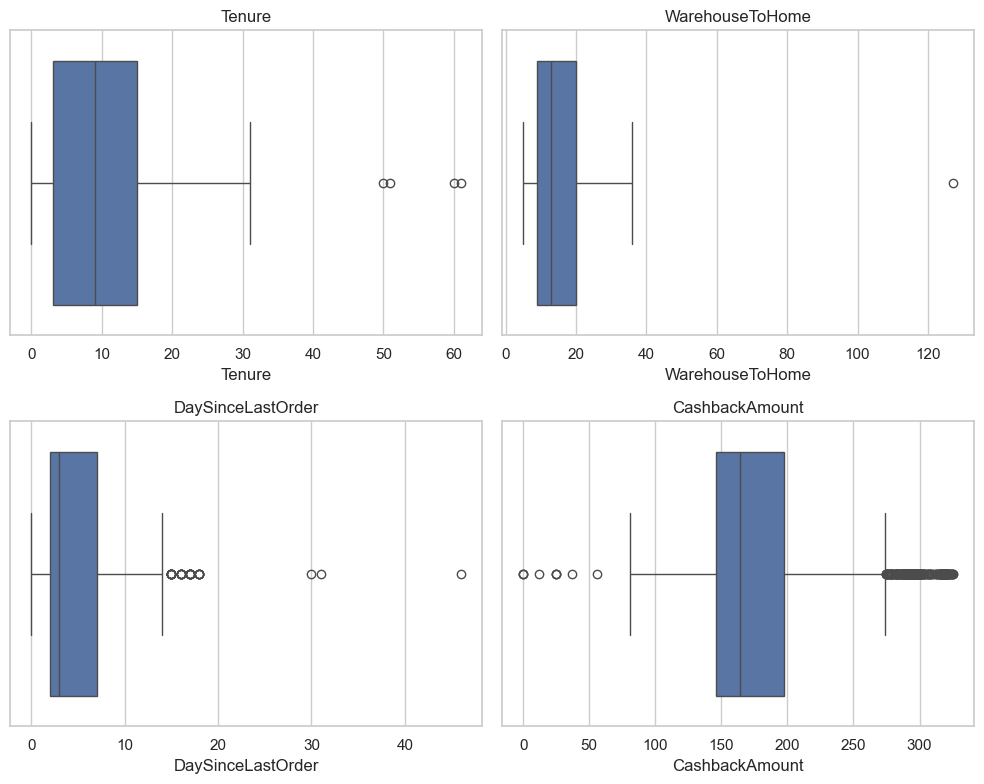

In [12]:
cols = ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder', 'CashbackAmount']

plt.figure(figsize=(10, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [13]:
df['Tenure'] = np.log1p(df['Tenure'])
df['WarehouseToHome'] = np.log1p(df['WarehouseToHome'])
df['DaySinceLastOrder'] = np.log1p(df['DaySinceLastOrder'])
df['CashbackAmount'] = np.log1p(df['CashbackAmount'])

Boxplots revealed the presence of outliers in:

- Tenure
- WarehouseToHome
- DaysSinceLastOrder
- CashbackAmount

Instead of removing outliers (which may contain valuable customer behavior),
log transformation was applied to reduce skewness and stabilize variance.

## Feature Engineering
To capture deeper customer behavior, new features were created:

In [14]:
df['Engagement_Score'] = df['Tenure'] / (df['DaySinceLastOrder'] + 1)
# Higher value indicates more active customers

df['Cashback_Per_Order'] = df['CashbackAmount'] / (df['Tenure'] + 1)
#Measures incentive dependency

df['Address_Stability'] = df['NumberOfAddress'] / (df['Tenure'] + 1)
#Indicates customer stability

df['Device_Per_Tenure'] = df['NumberOfDeviceRegistered'] / (df['Tenure'] + 1)
# Reflects device usage intensity


## Encoding


In [15]:
df = pd.get_dummies(df, columns=['PreferedOrderCat','MaritalStatus'],dtype = int)

In [16]:
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,Engagement_Score,...,Device_Per_Tenure,PreferedOrderCat_fashion,PreferedOrderCat_grocery,PreferedOrderCat_laptop & accessory,PreferedOrderCat_mobile phone,PreferedOrderCat_others,PreferedOrderCat_watch,MaritalStatus_divorced,MaritalStatus_married,MaritalStatus_single
0,2.772589,3.401197,4,3,2,0,2.079442,4.972033,0,0.900354,...,1.060280,0,0,1,0,0,0,0,0,1
1,2.079442,3.258097,4,1,2,0,2.079442,4.869763,0,0.675266,...,1.298937,0,0,0,0,0,1,0,1,0
2,3.332205,2.639057,3,1,5,0,2.079442,5.133089,0,1.082081,...,0.692488,0,0,1,0,0,0,0,1,0
3,3.044522,3.258097,4,3,7,0,1.386294,5.443586,0,1.275837,...,0.988992,1,0,0,0,0,0,1,0,0
4,3.433987,2.772589,4,4,8,0,2.197225,5.778179,0,1.074053,...,0.902123,0,0,0,0,1,0,0,0,1


## Correlation

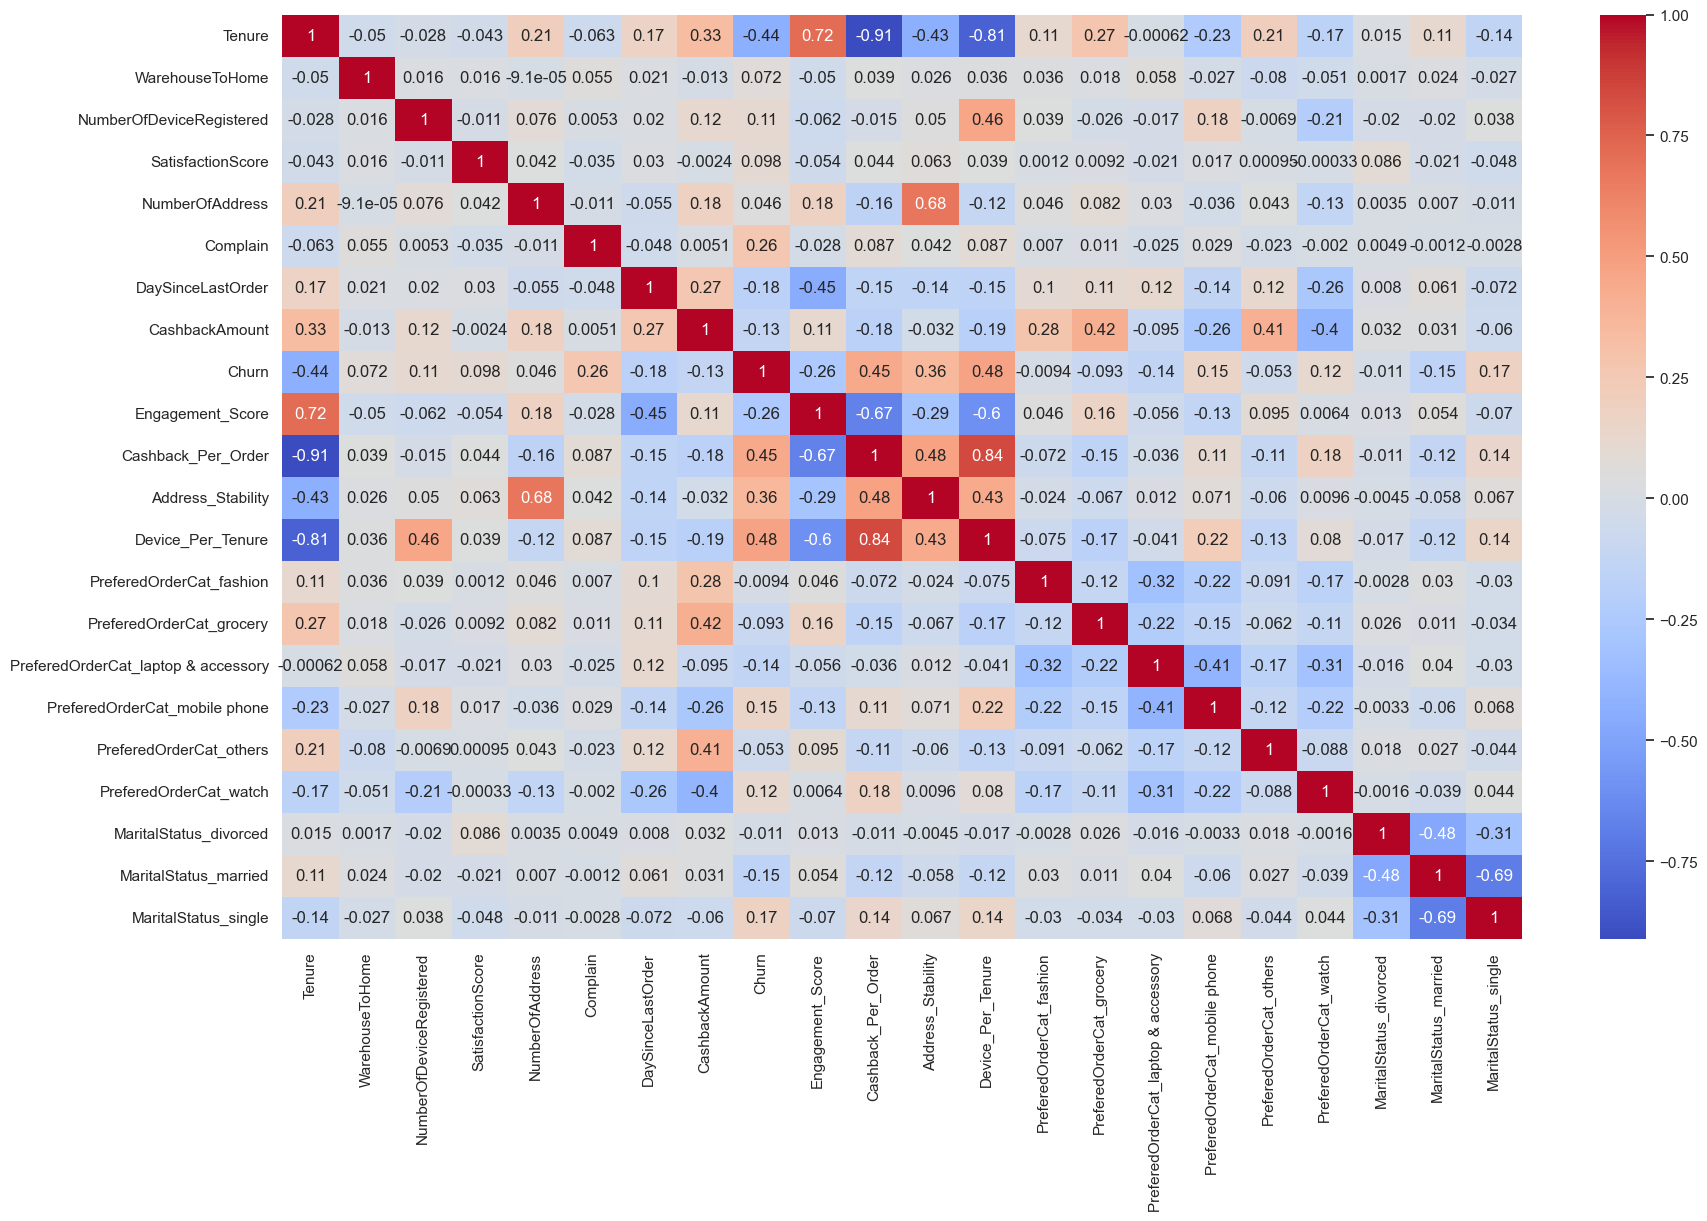

In [17]:
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [18]:
df.corr()['Churn'].sort_values(ascending=False)

Churn                                  1.000000
Device_Per_Tenure                      0.475540
Cashback_Per_Order                     0.447125
Address_Stability                      0.360139
Complain                               0.262278
MaritalStatus_single                   0.172694
PreferedOrderCat_mobile phone          0.152569
PreferedOrderCat_watch                 0.117303
NumberOfDeviceRegistered               0.109612
SatisfactionScore                      0.098393
WarehouseToHome                        0.071655
NumberOfAddress                        0.046354
PreferedOrderCat_fashion              -0.009409
MaritalStatus_divorced                -0.010994
PreferedOrderCat_others               -0.052891
PreferedOrderCat_grocery              -0.092952
CashbackAmount                        -0.125150
PreferedOrderCat_laptop & accessory   -0.135448
MaritalStatus_married                 -0.151188
DaySinceLastOrder                     -0.176238
Engagement_Score                      -0

Key factors positively correlated with churn:

- **Device per Tenure (0.47)**  
  → Customers using multiple devices are more likely to churn

- **Cashback per Order (0.44)**  
  → Customers dependent on discounts are less loyal

- **Address Stability (0.36)**  
  → Frequent address changes indicate unstable customers

- **Complaints (0.26)**  
  → Customers who complain are more likely to churn

Weak correlations:
- SatisfactionScore shows low correlation → may not be a strong standalone predictor

These insights guided feature selection for modeling.

#### Category-wise Insights

- Customers purchasing mobile-related products show higher churn rates
- Grocery customers show lower churn → more consistent behavior

This suggests:
- Product category influences retention
- High churn categories need targeted retention strategies

## Feature-Target Separation

The dataset was divided into:

- **X (features):** All independent variables
- **Y (target):** Churn (0 = No, 1 = Yes)

This separation allows the model to learn patterns that influence customer churn.

In [19]:
X = df.drop('Churn', axis = 1)
Y = df['Churn']

### Train-Test Split

The dataset was split into training (80%) and testing (20%) sets.

Stratified sampling was used to preserve the original churn distribution in both sets,
ensuring reliable model evaluation on imbalanced data.

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,
    test_size = 0.2,
    random_state = 42,
    stratify = Y

) 

In [21]:
X_train.to_csv("X_train.csv", index = False )
X_test.to_csv("X_test.csv", index = False)

Y_train.to_csv("Y_train.csv", index = False)
Y_test.to_csv("Y_test.csv", index = False)

In [22]:
df.to_csv("cleaned_full_data.csv", index = False)

In [23]:
df['Churn'].value_counts(normalize=True)

Churn
0    0.836697
1    0.163303
Name: proportion, dtype: float64

The dataset is:

- Non-churn: ~84%
- Churn: ~16%


## Model Building and Evaluation

In this section, multiple machine learning models are trained and evaluated to predict customer churn. 

Models used:
- Logistic Regression (for interpretability)
- Random Forest (for validation and non-linear patterns)
- XGBoost (for best predictive performance)

### Logistic Regression

In [24]:
log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train, Y_train)

Y_pred_log = log_model.predict(X_test)
Y_prob_log = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Results")
print(classification_report(Y_test, Y_pred_log))
print("AUC Score:", roc_auc_score(Y_test, Y_prob_log))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       547
           1       0.50      0.91      0.64       107

    accuracy                           0.83       654
   macro avg       0.74      0.86      0.77       654
weighted avg       0.90      0.83      0.85       654

AUC Score: 0.9255924413538588


#### Logistic Regression Performance

- Accuracy: 83%
- AUC Score: ~0.92

Key Insight:
- High recall (0.91) for churn → model identifies most churn customers
- Low precision (0.50) → many false positives

Conclusion:
This model is suitable when the business priority is to **not miss churn customers**,
even at the cost of targeting some non-churn users.

### Feature Importance ( Logistic Regression )

In [25]:
importance = pd.Series(log_model.coef_[0], index=X.columns)
importance.sort_values(ascending=False)

Complain                               1.478080
PreferedOrderCat_others                0.907726
Engagement_Score                       0.689863
Device_Per_Tenure                      0.524444
Address_Stability                      0.516739
WarehouseToHome                        0.516286
MaritalStatus_single                   0.469839
PreferedOrderCat_fashion               0.403019
PreferedOrderCat_watch                 0.172102
SatisfactionScore                      0.154260
NumberOfDeviceRegistered               0.066976
NumberOfAddress                       -0.030826
DaySinceLastOrder                     -0.089429
MaritalStatus_divorced                -0.199454
PreferedOrderCat_mobile phone         -0.201522
CashbackAmount                        -0.317960
PreferedOrderCat_grocery              -0.326290
Cashback_Per_Order                    -0.343384
MaritalStatus_married                 -0.395365
PreferedOrderCat_laptop & accessory   -1.080014
Tenure                                -1

### Random Forest Classifier

In [26]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, Y_train)

Y_pred_rf = rf.predict(X_test)
Y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Results")
print(classification_report(Y_test, Y_pred_rf))
print("AUC Score:", roc_auc_score(Y_test, Y_prob_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       547
           1       0.76      0.58      0.66       107

    accuracy                           0.90       654
   macro avg       0.84      0.77      0.80       654
weighted avg       0.89      0.90      0.90       654

AUC Score: 0.9509986502417604


#### Random Forest Performance

- Accuracy: ~90%
- AUC Score: ~0.95

Key Insight:
- Balanced performance between precision and recall
- Better overall classification than Logistic Regression

Conclusion:
Random Forest captures non-linear relationships and provides more stable predictions.

#### Feature Importance ( Random Forest)

In [30]:
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_importance.sort_values(ascending=False).head(10)

Cashback_Per_Order    0.152352
Engagement_Score      0.116797
Tenure                0.110175
CashbackAmount        0.100470
Address_Stability     0.086625
Device_Per_Tenure     0.083804
WarehouseToHome       0.061756
Complain              0.054632
SatisfactionScore     0.043176
DaySinceLastOrder     0.042916
dtype: float64

### XGBoost

In [31]:
xgb = XGBClassifier(scale_pos_weight=5, random_state=42)
xgb.fit(X_train, Y_train)

Y_pred_xgb = xgb.predict(X_test)
Y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost Results")
print(classification_report(Y_test, Y_pred_xgb))
print("AUC Score:", roc_auc_score(Y_test, Y_prob_xgb))

XGBoost Results
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       547
           1       0.74      0.81      0.78       107

    accuracy                           0.92       654
   macro avg       0.85      0.88      0.87       654
weighted avg       0.93      0.92      0.92       654

AUC Score: 0.9608570110543492


#### XGBoost Performance

- Accuracy: ~92%
- AUC Score: ~0.96

Key Insight:
- Best performance among all models
- Strong handling of imbalanced data
- Captures complex patterns effectively


### Model Comparison

In [32]:
print("Logistic:", roc_auc_score(Y_test, Y_prob_log))
print("Random Forest:", roc_auc_score(Y_test, Y_prob_rf))
print("XGBoost:", roc_auc_score(Y_test, Y_prob_xgb))

Logistic: 0.9255924413538588
Random Forest: 0.9509986502417604
XGBoost: 0.9608570110543492


### Model Selection Summary

Among all models, XGBoost achieved the highest AUC score, indicating the best performance in distinguishing between churn and non-churn customers.

Logistic Regression was used for interpretability, while Random Forest validated model robustness.

Therefore, XGBoost is selected as the final model.

### Business Decision:
- Logistic → Good for explainability
- Random Forest → Balanced performance
- XGBoost → Best predictive power (chosen

### XGBoost Model Configuration
--> To prevent overfitting and improve generalization, several regularization and control parameters are applied.

In [33]:

xgb = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=150,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    scale_pos_weight= len(Y_train[Y_train==0]) / len(Y_train[Y_train==1]),
    random_state=42
)

# Fit
xgb.fit(X_train, Y_train)

# Evaluate
train_prob = xgb.predict_proba(X_train)[:,1]
test_prob = xgb.predict_proba(X_test)[:,1]

print("Train AUC:", roc_auc_score(Y_train, train_prob))
print("Test AUC:", roc_auc_score(Y_test, test_prob))

Train AUC: 0.9551082001448588
Test AUC: 0.9518529276085359


### Model Generalization Check

- Train AUC: ~0.955
- Test AUC: ~0.951

#### Insight:
The small gap between train and test performance indicates:
- No significant overfitting
- Strong generalization capability

This confirms that the model performs reliably on unseen data.

## Probability Calibration

To improve probability reliability, calibration was applied using sigmoid method.


In [34]:
calibrated_xgb = CalibratedClassifierCV(xgb, method='sigmoid', cv=5)
calibrated_xgb.fit(X_train, Y_train)

calibrated_prob = calibrated_xgb.predict_proba(X_test)[:,1]

print("Calibrated AUC:", roc_auc_score(Y_test, calibrated_prob))

Calibrated AUC: 0.9495122076235714


#### Result:
- Calibrated probabilities provide more realistic risk estimates
- Essential for business decisions like targeting high-risk customers

#### Observation:
Calibration slightly reduced AUC but improved probability reliability.

### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of model predictions, showing true positives, true negatives, false positives, and false negatives.

This helps evaluate how well the model identifies churn customers and where misclassifications occur.

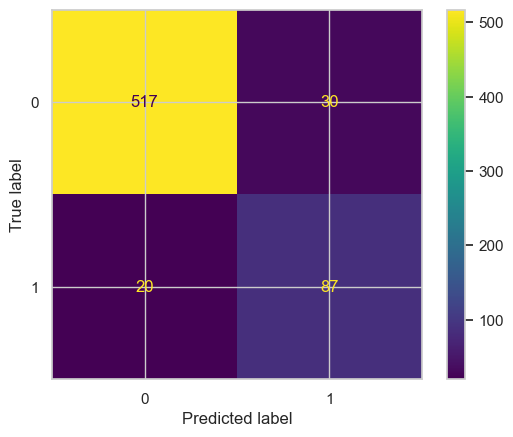

In [35]:
cm = confusion_matrix(Y_test, Y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#### Confusion Matrix Interpretation

- True Negatives (517): Correctly identified non-churn customers
- False Positives (30): Non-churn predicted as churn
- False Negatives (20): Missed churn customers (critical)
- True Positives (87): Correctly identified churn customers

##### Key Insight:
- Very low false negatives → model rarely misses actual churn customers
- Acceptable false positives → some extra customers may be targeted unnecessarily

#### Business Impact:
Minimizing false negatives is crucial, as missing a churn customer leads to direct revenue loss.

### Feature Importance Analysis

Feature importance helps identify the key factors driving customer churn.

The model highlights the most influential variables contributing to predictions, allowing us to understand customer behavior and design targeted strategies.

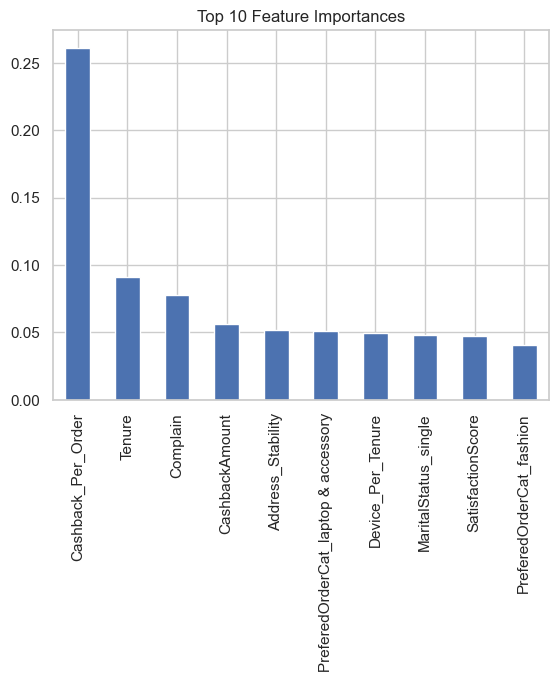

In [36]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

# Top 10 features
feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances")
plt.show()

### Feature Importance Insights

Top drivers of churn:

- **Cashback per Order**  
  → Customers relying on discounts are more likely to churn

- **Engagement Score**  
  → Lower engagement leads to higher churn risk

- **Tenure**  
  → New customers churn more frequently

- **Device per Tenure**  
  → Multi-device users show unstable behavior

- **Complaints**  
  → Direct indicator of dissatisfaction

#### Business Insight:
Retention strategies should focus on:
- Reducing complaint resolution time
- Increasing engagement
- Reducing over-dependence on discounts

### Risk Segmentation

Customers are segmented into Low, Medium, and High risk based on predicted churn probability.

In [37]:
df['Churn_Probability'] = calibrated_xgb.predict_proba(X)[:,1]
df['Churn_Percentage'] = df['Churn_Probability'] * 100
df['Risk_Level'] = pd.cut(df['Churn_Probability'], bins = [0,0.07,0.5,1], labels=['Low','Medium','High'])
df['Risk_Level'].value_counts()

Risk_Level
Low       2099
Medium     684
High       487
Name: count, dtype: int64

Customers are segmented based on predicted churn probability:

- Low Risk: 0 – 0.07
- Medium Risk: 0.07 – 0.5
- High Risk: 0.5 – 1

#### Rationale:
- Thresholds are chosen to clearly separate low-confidence and high-risk predictions
- High-risk group represents customers with strong churn signals

In [38]:
df.groupby('Risk_Level', observed = True)['Churn'].mean()

Risk_Level
Low       0.007146
Medium    0.225146
High      0.749487
Name: Churn, dtype: float64

#### Risk Segmentation Interpretation

Customers were segmented into Low, Medium, and High risk groups based on predicted churn probability.

The segmentation shows strong separation:
- Low-risk customers have very low churn rate (~1%)
- Medium-risk customers show moderate churn (~20–25%)
- High-risk customers have a very high churn rate (~75%)

This confirms that the model effectively distinguishes customer risk levels.

### High Risk Customer Analysis

Analysis of high-risk customers to identify key behavioral patterns.

In [39]:
High_Risk = df[df['Risk_Level'] == 'High']

High_Risk.mean(numeric_only=True)

Tenure                                  0.613854
WarehouseToHome                         2.756862
NumberOfDeviceRegistered                3.944559
SatisfactionScore                       3.291581
NumberOfAddress                         4.490760
Complain                                0.574949
DaySinceLastOrder                       1.073500
CashbackAmount                          5.019299
Churn                                   0.749487
Engagement_Score                        0.359996
Cashback_Per_Order                      3.600301
Address_Stability                       3.074550
Device_Per_Tenure                       2.780229
PreferedOrderCat_fashion                0.102669
PreferedOrderCat_grocery                0.008214
PreferedOrderCat_laptop & accessory     0.201232
PreferedOrderCat_mobile phone           0.425051
PreferedOrderCat_others                 0.004107
PreferedOrderCat_watch                  0.258727
MaritalStatus_divorced                  0.147844
MaritalStatus_marrie

--> Analysis of high-risk customers reveals distinct behavioral patterns:

#### Key Characteristics:

- **Very Low Tenure (~0.62)**  
  → High-risk customers are mostly new users with weak brand attachment

- **High Complaint Rate (~57%)**  
  → Strong dissatisfaction is a major churn driver

- **Low Engagement Score (~0.36)**  
  → Poor interaction with platform/services

- **High Cashback Dependency (~3.58 per order)**  
  → Customers rely heavily on incentives rather than loyalty

- **Moderate Satisfaction Score (~3.29)**  
  → Not terrible, but not strong enough to retain users

- **Higher Number of Addresses (~4.5)**  
  → Indicates instability or frequent changes in location

#### Key Insight:
High-risk customers are **low-engagement, incentive-driven, and dissatisfied users with weak long-term commitment**.

#### Critical Pattern Identified:

High-risk customers exhibit **"discount-dependent behavior"**, where:
- They engage only when incentives are provided
- They lack long-term loyalty
- They churn once incentives reduce

This indicates a **flawed retention strategy overly dependent on cashback offers**.

### Top 10% High-Risk Customers

Identifying customers with the highest churn probability for targeted retention strategies.

In [40]:
df_sorted = df.sort_values(by='Churn_Probability', ascending=False)

top_10 = df_sorted.head(int(0.1 * len(df)))

top_10.head(10)

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,Engagement_Score,...,PreferedOrderCat_laptop & accessory,PreferedOrderCat_mobile phone,PreferedOrderCat_others,PreferedOrderCat_watch,MaritalStatus_divorced,MaritalStatus_married,MaritalStatus_single,Churn_Probability,Churn_Percentage,Risk_Level
1155,0.000000,3.465736,4,4,5,1,1.098612,4.821329,1,0.000000,...,0,0,0,1,0,0,1,0.816343,81.634311,High
2919,0.000000,2.639057,4,5,7,1,0.000000,4.828634,1,0.000000,...,0,0,0,1,0,0,1,0.816072,81.607185,High
487,0.693147,2.890372,5,5,8,1,0.693147,5.010902,1,0.409384,...,0,1,0,0,0,0,1,0.811999,81.199936,High
136,0.693147,3.496508,5,4,6,1,1.386294,5.004818,1,0.290470,...,0,1,0,0,0,0,1,0.811620,81.162033,High
2663,0.000000,2.639057,3,5,6,1,1.609438,4.848665,1,0.000000,...,0,0,0,1,0,0,1,0.810886,81.088551,High
269,0.693147,2.079442,6,4,9,1,2.197225,4.998293,1,0.216797,...,0,1,0,0,0,0,1,0.810818,81.081847,High
588,0.693147,3.465736,5,3,7,1,1.609438,4.985523,1,0.265631,...,0,1,0,0,0,0,1,0.806700,80.670020,High
797,0.000000,2.639057,4,5,2,1,0.000000,4.844187,1,0.000000,...,0,0,0,1,0,0,1,0.806559,80.655927,High
2410,0.000000,2.639057,4,5,5,1,0.000000,4.823100,1,0.000000,...,0,0,0,1,0,1,0,0.806423,80.642322,High
2244,0.693147,2.302585,5,3,8,1,0.693147,4.989752,1,0.409384,...,0,1,0,0,0,0,1,0.805660,80.565976,High


#### Key Observations:

- Many customers have **zero or very low tenure**
- Almost all have **complaints registered**
- Engagement is consistently low
- Frequent address changes indicate instability

#### Insight:
This segment contains customers who are **on the verge of churn and require immediate action**.

## Target Customer Strategy

The top 10% high-risk customers should be prioritized for immediate retention actions.

### Recommended Actions:

#### 1. Complaint Resolution Strategy
- Proactively address customer complaints within 24–48 hours
- Provide personalized support to dissatisfied users

#### 2. Reduce Cashback Dependency
- Replace blanket cashback offers with personalized incentives
- Focus on value-driven engagement instead of discounts

#### 3. Engagement Boosting
- Send targeted notifications and personalized recommendations
- Improve onboarding experience for new users

#### 4. Loyalty Building
- Introduce loyalty programs for low-tenure customers
- Encourage repeat purchases through non-monetary incentives

---

### Business Impact:

- Reducing churn in this segment can significantly increase revenue retention
- Targeted strategies ensure efficient use of marketing resources
- Improves customer lifetime value

## Final Conclusion

This project demonstrates how machine learning can be used to not only predict churn but also drive actionable business decisions.

Key achievements:

- Built a high-performing churn prediction model (AUC ~0.96)
- Identified key drivers of churn such as low tenure, complaints, and low engagement
- Segmented customers into meaningful risk groups
- Designed targeted retention strategies based on behavioral insights

### Final Insight:

Churn is not random — it is driven by identifiable behavioral patterns.

By leveraging predictive modeling and customer segmentation, businesses can move from **reactive churn handling to proactive retention strategy**.

## SQL Integration

To enable efficient querying and integration with BI tools, the processed dataset was stored in a SQLite database.

In [41]:
import sqlite3
conn = sqlite3.connect("Churn_Prediction.db")

In [42]:
df_final = df_original.copy()

In [43]:
df_final['Engagement_Score'] = df_final['Tenure'] / (df_final['DaySinceLastOrder'] + 1)
# Higher value indicates more active customers

df_final['Cashback_Per_Order'] = df_final['CashbackAmount'] / (df_final['Tenure'] + 1)
#Measures incentive dependency

df_final['Address_Stability'] = df_final['NumberOfAddress'] / (df_final['Tenure'] + 1)
#Indicates customer stability

df_final['Device_Per_Tenure'] = df_final['NumberOfDeviceRegistered'] / (df_final['Tenure'] + 1)
# Reflects device usage intensity


In [44]:

# add model outputs
df_final['Churn_Probability'] = calibrated_xgb.predict_proba(X)[:,1]
df_final['Churn_Percentage'] = df['Churn_Probability']*100
df_final['Risk_Level'] = pd.cut(df_final['Churn_Probability'],
                               bins=[0,0.3,0.7,1],
                               labels=['Low','Medium','High'])

### Storing Data in SQL


In [45]:
df_final.to_sql("Churn_Predictions", conn, if_exists="replace", index=False)

3270

In [46]:
import pandas as pd

pd.read_sql("SELECT * FROM Churn_Predictions LIMIT 5", conn)

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,Engagement_Score,Cashback_Per_Order,Address_Stability,Device_Per_Tenure,Churn_Probability,Churn_Percentage,Risk_Level
0,15.0,29.0,4,laptop & accessory,3,single,2,0,7.0,143.32,0,1.875000,8.957500,0.125000,0.250000,0.022066,2.206638,Low
1,7.0,25.0,4,watch,1,married,2,0,7.0,129.29,0,0.875000,16.161250,0.250000,0.500000,0.025411,2.541054,Low
2,27.0,13.0,3,laptop & accessory,1,married,5,0,7.0,168.54,0,3.375000,6.019286,0.178571,0.107143,0.013454,1.345414,Low
3,20.0,25.0,4,fashion,3,divorced,7,0,3.0,230.27,0,5.000000,10.965238,0.333333,0.190476,0.040770,4.076994,Low
4,30.0,15.0,4,others,4,single,8,0,8.0,322.17,0,3.333333,10.392581,0.258065,0.129032,0.015225,1.522450,Low


In [47]:
conn.close()

## Exporting SQL Data for Power BI

In [48]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("Churn_Prediction.db")

df = pd.read_sql("SELECT * FROM Churn_Predictions", conn)

df.to_csv("churn_data.csv", index=False)

In [49]:
import joblib
joblib.dump(calibrated_xgb, "model.pkl")
joblib.dump(X_train.columns.tolist(), "columns.pkl")

['columns.pkl']